# Dual Active Bridge (DAB) Converter — Transformer Design and Analysis

### Design Specifications

| Property | Symbol | Value | Unit |
|---|---|---|---|
| Nominal output power | $P_\mathrm{out,nom}$ | 50 | W |
| Nominal input voltage | $U_\mathrm{in,nom}$ | 50 | V |
| Minimum input voltage | $U_\mathrm{in,min}$ | 30 | V |
| Maximum input voltage | $U_\mathrm{in,max}$ | 60 | V |
| Output voltage | $U_\mathrm{out}$ | 12 | V |
| Output voltage ripple (rel.) | $\Delta U_\mathrm{out,pp,rel}$ | 2 | % |
| Switching frequency | $f_\mathrm{sw}$ | 40 | kHz |
| Auxiliary output voltage | $V_\mathrm{aux,out} $ | 18 | V |
| Auxiliary output power | $P_\mathrm{aux,out} $ | 5 | W |

In [33]:

import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Configure matplotlib for high-resolution plots
plt.rcParams['figure.dpi'] = 150           # High-res display
plt.rcParams['savefig.dpi'] = 300          # High-res when saving
plt.rcParams['font.size'] = 10             # Readable font size
plt.rcParams['axes.linewidth'] = 1.2       # Slightly thicker axes
plt.rcParams['grid.alpha'] = 0.3           # Subtle grid
plt.rcParams['lines.linewidth'] = 2        # Thicker plot lines

In [35]:
# === Design Specifications ===
P_out_nom = 50          # Nominal output power [W]
U_in_nom  = 50          # Nominal input voltage [V]
U_in_min  = 30          # Minimum input voltage [V]
U_in_max  = 60          # Maximum input voltage [V]
U_out     = 12          # Output voltage [V]
dU_out_rel = 0.02       # Output voltage ripple (relative) [-]
f_sw      = 80e3        # Switching frequency [Hz]
V_aux_out = 18          # Auxiliary output voltage [V]
P_aux_out = 5           # Auxiliary output power [W]

# === Derived Quantities ===
T_sw      = 1 / f_sw                       # Switching period [s]
dU_out_pp = dU_out_rel * U_out             # Absolute output voltage ripple [V]

print(f"Switching period  T_sw  = {T_sw*1e6:.1f} µs")
print(f"Output ripple     ΔU_pp = {dU_out_pp*1e3:.0f} mV")

# === Selected Design Variables ===
N = 4.17                 # Transformer turns ratio [-]
C_in = 700e-6            # Input capacitor [F]
L = 26.04e-6             # Inductance [H]
C_DCblock = 15.20e-6     # DC-blocking capacitor [F]
C_out = 152.72e-6        # Output capacitor [F]

print(f"N          = {N:.2f} [-]")
print(f"C_in       = {C_in*1e6:.2f} µF")
print(f"L          = {L*1e6:.2f} µH")
print(f"C_DCblock  = {C_DCblock*1e6:.2f} µF")
print(f"C_out      = {C_out*1e6:.2f} µF")


Switching period  T_sw  = 12.5 µs
Output ripple     ΔU_pp = 240 mV
N          = 4.17 [-]
C_in       = 700.00 µF
L          = 26.04 µH
C_DCblock  = 15.20 µF
C_out      = 152.72 µF


## Q1: Calculation of Volt-Second Stress

The volt-second stress (peak flux-linkage) on the primary side is defined as the integral of the voltage applied to the transformer over one positive half cycle. In a DAB converter, both bridges operate at 50% duty cycle, so the full input voltage is applied for half the switching period:

$$\lambda_1 = U_\mathrm{in} \cdot \frac{T_\mathrm{sw}}{2}$$

The worst case (highest $\lambda_1$) occurs at **maximum input voltage** $U_\mathrm{in,max}$.

In [36]:
# Q1: Volt-second stress (primary side)
lambda_1_max = U_in_max * T_sw / 2

print(f"Worst-case volt-second stress: λ₁,max = {lambda_1_max*1e6:.1f} µV·s , ([V·s] = [Wb])")

Worst-case volt-second stress: λ₁,max = 375.0 µV·s , ([V·s] = [Wb])


## Q2: Estimation of Loss Coefficient $K_\mathrm{fe}$

The volumetric core loss at 80°C is given by the Steinmetz equation:

$$p_\mathrm{vol} = K_\mathrm{b} \cdot \left(\frac{f}{f_\mathrm{base}}\right)^{\alpha} \cdot \left(\frac{B_\mathrm{pk}}{B_\mathrm{base}}\right)^{\beta}$$

To express this as $p_\mathrm{vol} = K_\mathrm{fe} \cdot B_\mathrm{pk}^{\beta}$, we absorb the frequency dependence into $K_\mathrm{fe}$:

$$K_\mathrm{fe} = K_\mathrm{b} \cdot \left(\frac{f_\mathrm{sw}}{f_\mathrm{base}}\right)^{\alpha} \cdot \frac{1}{B_\mathrm{base}^{\beta}}$$

The nearest base frequency to $f_\mathrm{sw} = 80\,\mathrm{kHz}$ is **100 kHz**.

| $f_\mathrm{base}$ (kHz) | $\alpha$ | $\beta$ | $K_\mathrm{b}$ (kW/m³) | $B_\mathrm{base}$ (mT) |
|---|---|---|---|---|
| **100** | **1.72** | **2.68** | **61.15** | **100** |

In [37]:
# Q2: Core loss coefficient K_fe
# Steinmetz parameters for nearest base frequency (100 kHz row, N87 material)
f_base = 100e3          # Base frequency [Hz]
alpha  = 1.72           # Steinmetz frequency exponent [-]
beta   = 2.68           # Steinmetz flux exponent [-]
K_b    = 61.15e3        # Base volumetric loss coefficient [W/m³]
B_base = 100e-3         # Base peak flux density [T]

# K_fe such that p_vol = K_fe * B_pk^beta
K_fe = K_b * (f_sw / f_base)**alpha / B_base**beta

print(f"K_fe = {K_fe:.2f} W/(m³·T^{beta})")
print(f"K_fe = {K_fe/1e6:.4f} MW/(m³·T^{beta})")

K_fe = 19939361.12 W/(m³·T^2.68)
K_fe = 19.9394 MW/(m³·T^2.68)


## Q3: Total Current Stress

The total RMS current stress for the $K_g$ method is:

$$I_\mathrm{tot} = \sum_{j=1}^{k} n_j \cdot I_{j,\mathrm{RMS}}, \qquad n_j = \frac{N_j}{N_1}$$

For a DAB, the inductor current $i_L$ flows through the primary, and by transformer action $I_2 = N \cdot I_1$. Since $n_2 = 1/N$:

$$n_2 \cdot I_{2,\mathrm{RMS}} = \frac{1}{N} \cdot N \cdot I_{1,\mathrm{RMS}} = I_{1,\mathrm{RMS}}$$

Therefore:

$$I_\mathrm{tot} = 2 \cdot I_{1,\mathrm{RMS}} + n_\mathrm{aux} \cdot I_\mathrm{w,aux,RMS}$$

The worst case (highest RMS current) occurs at **minimum input voltage** $U_\mathrm{in,min}$, where the voltage mismatch causes higher circulating currents.

In [38]:
# Q3: Total current stress I_tot

# Given
I_aux_RMS = 0.8                          # Worst-case auxiliary RMS current [A]
n_aux = V_aux_out / U_in_nom             # Auxiliary turns ratio N_aux/N_1 ≈ V_aux/U_in_nom

# DAB worst case: U_in_min with nominal output power
V_1  = U_in_min                          # Primary-side voltage [V]
V_2p = N * U_out                         # Reflected secondary voltage to primary [V]
omega_L = 2 * np.pi * f_sw * L           # ωL [Ω]

# Phase shift δ from power equation:
#   P = V_1 · V_2' · δ · (π − δ) / (2π² · f_sw · L)
rhs = P_out_nom * 2 * np.pi**2 * f_sw * L / (V_1 * V_2p)
delta = (np.pi - np.sqrt(np.pi**2 - 4 * rhs)) / 2   # [rad]

# Current at switching instants (half-wave symmetry: i(π) = −i(0))
i_0     = -(V_1 * np.pi - V_2p * (np.pi - 2*delta)) / (2 * omega_L)
i_delta =  i_0 + (V_1 + V_2p) * delta / omega_L

# RMS current over half period [0, π] — piecewise-linear waveform
# Segment 1: [0, δ]  i(θ) = i_0 + slope_1·θ,  from i_0 → i_δ
slope_1 = (i_delta - i_0) / delta
int_1   = i_0**2 * delta + i_0 * slope_1 * delta**2 + slope_1**2 * delta**3 / 3

# Segment 2: [δ, π]  i(θ) = i_δ + slope_2·(θ−δ),  from i_δ → −i_0
dur_2   = np.pi - delta
slope_2 = (-i_0 - i_delta) / dur_2
int_2   = i_delta**2 * dur_2 + i_delta * slope_2 * dur_2**2 + slope_2**2 * dur_2**3 / 3

I_1_RMS = np.sqrt((int_1 + int_2) / np.pi)

# Total current stress
I_tot = 2 * I_1_RMS + n_aux * I_aux_RMS

print(f"Reflected secondary voltage  V₂' = N·U_out = {V_2p:.2f} V")
print(f"Phase shift                  δ   = {np.degrees(delta):.1f}°")
print(f"Current at θ=0               i₀  = {i_0:.3f} A")
print(f"Current at θ=δ               iδ  = {i_delta:.3f} A")
print(f"Primary RMS current          I₁,RMS = {I_1_RMS:.3f} A")
print(f"Auxiliary turns ratio         n_aux  = {n_aux:.3f}")
print(f"")
print(f"I_tot = 2 × {I_1_RMS:.3f} + {n_aux:.3f} × {I_aux_RMS:.1f} = {I_tot:.3f} A")

Reflected secondary voltage  V₂' = N·U_out = 50.04 V
Phase shift                  δ   = 30.0°
Current at θ=0               i₀  = 0.405 A
Current at θ=δ               iδ  = 3.604 A
Primary RMS current          I₁,RMS = 2.015 A
Auxiliary turns ratio         n_aux  = 0.360

I_tot = 2 × 2.015 + 0.360 × 0.8 = 4.317 A


## Q4: Window Utilization Factor

The window utilization factor $K_u$ (fill factor) accounts for insulation, bobbin walls, air gaps between round conductors, and the space lost to multiple winding layers.

For a bobbin-wound transformer with multiple windings and insulation layers, typical values are $K_u \approx 0.25 - 0.4$.

A conservative first estimate for our design: **$K_u = 0.3$**.

In [39]:
# Q4: Window utilization factor
K_u = 0.3   # Conservative estimate for bobbin-wound, multi-winding transformer [-]

print(f"Window utilization factor  K_u = {K_u}")

Window utilization factor  K_u = 0.3


## Q5: Estimation of Loss Budget

Target a reasonable converter efficiency $\eta$ and compute the total allowed losses:

$$P_\mathrm{tot} = P_\mathrm{out,nom} \cdot \frac{1 - \eta}{\eta}$$

For a 50 W DAB converter at 80 kHz (student design), a target efficiency of **$\eta = 95\%$** is a reasonable first estimate.

In [40]:
# Q5: Loss budget
eta = 0.95                                # Target converter efficiency [-]
P_tot = P_out_nom * (1 - eta) / eta       # Total allowed losses [W]

print(f"Target efficiency  η     = {eta*100:.0f} %")
print(f"Total loss budget  P_tot = {P_tot:.2f} W")

Target efficiency  η     = 95 %
Total loss budget  P_tot = 2.63 W


---
## Section 2: Core Selection (Q6–Q13)

## Q6: Maximum Value of Peak Flux Density

The maximum allowable peak flux density $B_\mathrm{pk,max}$ is selected from the N87 magnetization curves as a conservative design limit — well below the saturation flux density.

From the TDK N87 datasheet:
- $B_\mathrm{sat}(25\,^\circ\mathrm{C}) = 490\,\mathrm{mT}$
- $B_\mathrm{sat}(100\,^\circ\mathrm{C}) = 390\,\mathrm{mT}$

At elevated operating temperature the B-H loop shows significant nonlinearity above ~300 mT. We select:

$$B_\mathrm{pk,max} = 300\,\mathrm{mT}$$

This is below saturation at 100 °C (390 mT) and limits core losses to an acceptable level.

In [41]:
# Q6: Maximum peak flux density
B_pk_max = 0.300   # T — design limit from N87 magnetization curve at 100°C

print(f"B_pk,max = {B_pk_max*1e3:.0f} mT")

B_pk,max = 300 mT


## Q7: Minimum $K_\mathrm{gfe}$

Using $\beta = 2.7$ (average for ferrites, as specified), the loss coefficient is recomputed:

$$K_\mathrm{fe} = K_b \cdot \left(\frac{f_\mathrm{sw}}{f_\mathrm{base}}\right)^{\alpha} \cdot \frac{1}{B_\mathrm{base}^{\beta}}$$

The minimum geometric core constant required is (all quantities in cm-unit system, $\rho$ in $\Omega\cdot\mathrm{cm}$, $\lambda_1$ in V·s):

$$K_\mathrm{gfe,min} = \frac{\rho \cdot \lambda_1^2 \cdot I_\mathrm{tot}^2}{K_\mathrm{fe}^{2/\beta} \cdot 4 \cdot K_u \cdot P_\mathrm{tot}^{(\beta+2)/\beta}} \times 10^8 \quad [\mathrm{cm}^5]$$

The $\times 10^8$ factor is the SI→cm unit conversion inherent to the cm-unit formula.

In [42]:
# Q7: Minimum K_gfe (using β = 2.7 as specified)
beta  = 2.7          # Steinmetz flux exponent (rounded as per Q7 instruction)

# Recompute K_fe with β = 2.7 (cm-unit system: W/(cm³·T^β))
K_fe_cm = K_b * (f_sw / f_base)**alpha / B_base**beta / 1e6   # W/(cm³·T^β)

# Parameters in cm-unit system
rho_cm   = 1.724e-6   # Copper resistivity [Ω·cm]
lambda1  = lambda_1_max          # Volt-second stress [V·s]

# K_gfe,min formula (× 10^8 = SI→cm unit conversion)
K_gfe_min = (rho_cm * lambda1**2 * I_tot**2 * K_fe_cm**(2/beta) /
             (4 * K_u * P_tot**((beta+2)/beta))) * 1e8

print(f"K_fe (β=2.7)    = {K_fe_cm:.4f} W/(cm³·T^β)")
print(f"")
print(f"K_gfe,min       = {K_gfe_min:.4e} cm⁵")
print(f"")
print(f"Available cores (K_gfe in cm⁵):")
cores = {"E20": 0.0019, "E25": 0.0044, "E30": 0.0049, "E32": 0.0090,
         "ETD34": 0.0120, "ETD39": 0.0197, "ETD44": 0.0290}
for name, kgfe in cores.items():
    ok = "✓" if kgfe >= K_gfe_min else "✗"
    print(f"  {name:6s}: K_gfe = {kgfe:.4f} cm⁵  {ok}")
print(f"\nAll cores satisfy K_gfe ≥ K_gfe,min — core selection driven by winding fit.")

K_fe (β=2.7)    = 20.8791 W/(cm³·T^β)

K_gfe,min       = 6.6364e-04 cm⁵

Available cores (K_gfe in cm⁵):
  E20   : K_gfe = 0.0019 cm⁵  ✓
  E25   : K_gfe = 0.0044 cm⁵  ✓
  E30   : K_gfe = 0.0049 cm⁵  ✓
  E32   : K_gfe = 0.0090 cm⁵  ✓
  ETD34 : K_gfe = 0.0120 cm⁵  ✓
  ETD39 : K_gfe = 0.0197 cm⁵  ✓
  ETD44 : K_gfe = 0.0290 cm⁵  ✓

All cores satisfy K_gfe ≥ K_gfe,min — core selection driven by winding fit.


## Q8: Selection of the Core

Since $K_\mathrm{gfe,min}$ is much smaller than all available cores, the K_gfe constraint is trivially satisfied. The actual binding constraint comes from fitting the required number of turns and wire cross-sections within the available window area (verified in Q9–Q21).

Starting from the smallest core (E20) and iterating upward:

| Core | $K_\mathrm{gfe}$ | B_opt (mT) | N₁,opt | A_w,pri,max (mm²) | A_TC,pri (mm²) | Fit? |
|---|---|---|---|---|---|---|
| E20 | 0.0019 | ~229 | ~26 | ~0.22 | 0.504 | ✗ too small |
| E25 | 0.0044 | ~146 | ~25 | ~0.38 | 0.504 | ✗ marginal |
| ETD34 | 0.0120 | ~86 | ~23 | 0.683 | 0.504 | ✓ comfortable |

**Selected core: ETD34/17/11** with N87 material and B66362 coil former.

**ETD34/17/11 geometry:**
- $A_e = 97.1\,\mathrm{mm}^2 = 0.971\,\mathrm{cm}^2$, $A_\mathrm{min} = 91.6\,\mathrm{mm}^2$
- $l_e = 78.6\,\mathrm{mm}$, $V_e = 7630\,\mathrm{mm}^3$
- $A_N = 122\,\mathrm{mm}^2 = 1.22\,\mathrm{cm}^2$ (coil former window)
- $\mathrm{MLT} = 60.5\,\mathrm{mm} = 6.05\,\mathrm{cm}$
- $A_L = 2600\,\mathrm{nH}$ (N87, ungapped), $R_\mathrm{th} = 20\,\mathrm{K/W}$

In [43]:
# Q8: ETD34/17/11 core parameters
A_c   = 0.971    # Effective cross-section area  [cm²]
l_m   = 7.86     # Effective magnetic path length [cm]
V_e   = 7.63     # Effective volume              [cm³]
W_A   = 1.22     # Coil former window area       [cm²]
MLT   = 6.05     # Mean length per turn          [cm]
A_L   = 2600e-9  # Inductance factor (N87, ungapped) [H]
R_th  = 20.0     # Thermal resistance core→ambient   [K/W]

K_gfe_ETD34 = 0.0120  # cm⁵ (from table, β=2.7)

print(f"Selected core:  ETD34/17/11 (N87)")
print(f"  A_c  = {A_c:.3f} cm²     l_m  = {l_m:.2f} cm")
print(f"  V_e  = {V_e:.2f} cm³     W_A  = {W_A:.2f} cm²")
print(f"  MLT  = {MLT:.2f} cm      A_L  = {A_L*1e9:.0f} nH")
print(f"  R_th = {R_th:.0f} K/W     K_gfe= {K_gfe_ETD34:.4f} cm⁵ > {K_gfe_min:.2e} ✓")

Selected core:  ETD34/17/11 (N87)
  A_c  = 0.971 cm²     l_m  = 7.86 cm
  V_e  = 7.63 cm³     W_A  = 1.22 cm²
  MLT  = 6.05 cm      A_L  = 2600 nH
  R_th = 20 K/W     K_gfe= 0.0120 cm⁵ > 6.64e-04 ✓


## Q9: Verification of the Peak Flux Density

The optimal flux density (minimizing combined copper + core losses) for the selected core is:

$$B_\mathrm{opt} = \left[\frac{\rho \cdot \lambda_1^2 \cdot \mathrm{MLT} \cdot I_\mathrm{tot}^2}{2\beta \cdot K_u \cdot W_A \cdot A_c^3 \cdot K_\mathrm{fe} \cdot l_m} \times 10^8 \right]^{1/(\beta+2)}$$

The actual $\Delta B$ for the chosen integer $N_1$ is then:

$$\Delta B = \frac{\lambda_1}{2 N_1 A_c} \times 10^4$$

(with $\lambda_1$ in V·s, $A_c$ in cm²)

In [44]:
# Q9: Optimal flux density and actual ΔB

# Optimal B (from loss minimization, ×10^8 is SI→cm unit conversion)
B_opt_pow = (rho_cm * lambda1**2 * MLT * I_tot**2 * 1e8 /
             (2 * beta * K_u * W_A * A_c**3 * K_fe_cm * l_m))
B_opt = B_opt_pow**(1/(beta + 2))

print(f"Optimal flux density:  B_opt = {B_opt*1e3:.1f} mT")
print(f"")

# N1 from optimal B (preliminary; will be rounded for correct turns ratio in Q10)
N1_opt = lambda1 / (2 * B_opt * A_c) * 1e4
print(f"Optimal primary turns: N1,opt = {N1_opt:.1f}  (round for integer turns ratio in Q10)")
print(f"")

# Chosen N1 = 25 (gives exact turns ratio n = 25/6 ≈ 4.167 ≈ N)
N1 = 25
B_actual = lambda1 / (2 * N1 * A_c) * 1e4

print(f"Chosen N1 = {N1}  →  ΔB = {B_actual*1e3:.1f} mT")
print(f"Check:  ΔB = {B_actual*1e3:.1f} mT  <  B_pk,max = {B_pk_max*1e3:.0f} mT  →  {'✓ OK' if B_actual < B_pk_max else '✗ FAIL'}")

Optimal flux density:  B_opt = 84.8 mT

Optimal primary turns: N1,opt = 22.8  (round for integer turns ratio in Q10)

Chosen N1 = 25  →  ΔB = 77.2 mT
Check:  ΔB = 77.2 mT  <  B_pk,max = 300 mT  →  ✓ OK


## Q10: Required Number of Turns

The desired turns ratios are:
$$n = \frac{U_\mathrm{in,nom}}{N \cdot U_\mathrm{out}} \approx \frac{50}{4.17 \times 12} \approx 4.17, \qquad n_\mathrm{aux} = \frac{V_\mathrm{aux,out}}{U_\mathrm{in,nom}} = \frac{18}{50} = 0.36$$

$N_1$ is chosen to simultaneously satisfy $n = N_1/N_2 \approx 4.17$ with integer turns.
$N_2 = \mathrm{round}(N_1/n)$, $N_\mathrm{aux} = \mathrm{round}(n_\mathrm{aux} \cdot N_1)$.

In [45]:
# Q10: Number of turns

n_desired     = N          # Target main turns ratio (4.17)
n_aux_desired = V_aux_out / U_in_nom   # Target auxiliary turns ratio (0.36)

# N1 = 25 chosen so that N2 = round(25/4.17) = 6 gives n_real ≈ 4.167
N1    = 25
N2    = round(N1 / n_desired)
N_aux = round(n_aux_desired * N1)

n_real      = N1 / N2
n_aux_real  = N_aux / N1
V_aux_real  = n_aux_real * U_in_nom

print(f"Desired  n      = {n_desired:.4f},   n_aux    = {n_aux_desired:.4f}")
print(f"")
print(f"N1 = {N1},  N2 = {N2},  N_aux = {N_aux}")
print(f"")
print(f"Actual   n_real = {n_real:.4f}  (err = {abs(n_real-n_desired)/n_desired*100:.2f}%)")
print(f"Actual   n_aux  = {n_aux_real:.4f}  (err = {abs(n_aux_real-n_aux_desired)/n_aux_desired*100:.2f}%)")
print(f"V_aux,real = {V_aux_real:.1f} V  (target {V_aux_out} V, err = {abs(V_aux_real-V_aux_out)/V_aux_out*100:.1f}%)")

Desired  n      = 4.1700,   n_aux    = 0.3600

N1 = 25,  N2 = 6,  N_aux = 9

Actual   n_real = 4.1667  (err = 0.08%)
Actual   n_aux  = 0.3600  (err = 0.00%)
V_aux,real = 18.0 V  (target 18 V, err = 0.0%)


## Q11: Magnetizing Inductance

The magnetizing inductance must be large enough so that the magnetising current is negligible compared to the load current:

$$L_{m,\mathrm{MIN}} = 10 \times L = 10 \times 26.04\,\mu\mathrm{H} = 260.4\,\mu\mathrm{H}$$

For the ungapped ETD34 core with $A_L = 2600\,\mathrm{nH}$:

$$L_m = A_L \cdot N_1^2$$

In [46]:
# Q11: Magnetizing inductance
L_m_MIN = 10 * L        # Minimum required magnetizing inductance [H]
L_m     = A_L * N1**2  # Actual magnetizing inductance [H]

print(f"L_m,MIN = {L_m_MIN*1e6:.1f} µH")
print(f"L_m     = A_L × N1² = {A_L*1e9:.0f} nH × {N1}² = {L_m*1e6:.1f} µH")
print(f"Check:  L_m = {L_m*1e6:.0f} µH  >>  L_m,MIN = {L_m_MIN*1e6:.1f} µH  →  {'✓ OK' if L_m >= L_m_MIN else '✗ FAIL'}")

L_m,MIN = 260.4 µH
L_m     = A_L × N1² = 2600 nH × 25² = 1625.0 µH
Check:  L_m = 1625 µH  >>  L_m,MIN = 260.4 µH  →  ✓ OK


## Q12: Power Margin with Realized Turns Ratio

With the realized $n_\mathrm{real} = N_1/N_2$, the maximum transferable power is:

$$P_\mathrm{max}(V_\mathrm{in}) = \frac{V_\mathrm{in} \cdot n_\mathrm{real} \cdot U_\mathrm{out}}{8 f_\mathrm{sw} L} $$


We must verify $P_\mathrm{max}(V_\mathrm{in,min}) \geq P_\mathrm{out,nom}$.

P_max at V_in,min = 30 V:  90.0 W  ✓ ≥ P_out,nom = 50 W
P_max at V_in,nom = 50 V:  150.0 W
P_max at V_in,max = 60 V:  180.0 W


FileNotFoundError: [Errno 2] No such file or directory: 'Plots/Q12-power-margin.png'

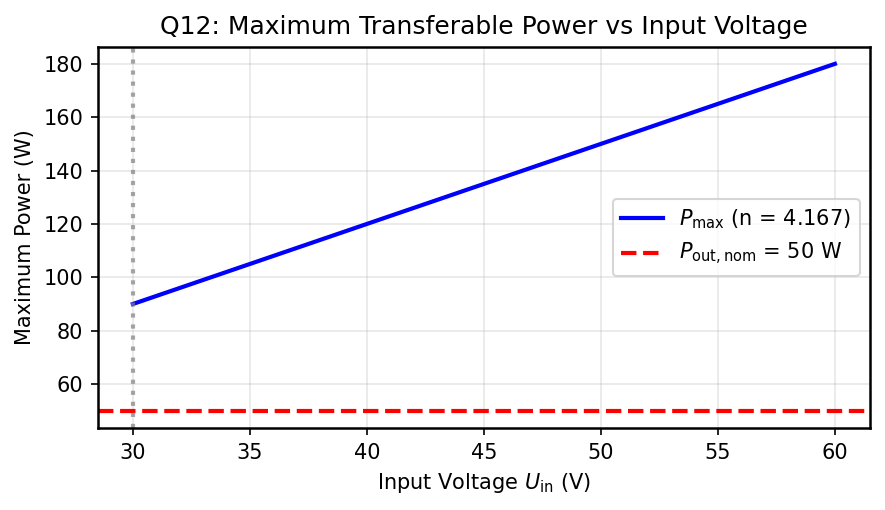

In [47]:
# Q12: Maximum power with realized turns ratio
def P_max_DAB(V_in, n, U_out, f_sw, L):
    """Maximum transferable power at delta = pi/2."""
    return V_in * n * U_out / (8 * f_sw * L)

P_max_min = P_max_DAB(U_in_min, n_real, U_out, f_sw, L)
P_max_nom = P_max_DAB(U_in_nom, n_real, U_out, f_sw, L)
P_max_max = P_max_DAB(U_in_max, n_real, U_out, f_sw, L)

print(f"P_max at V_in,min = {U_in_min} V:  {P_max_min:.1f} W  "
      f"{'✓ ≥ P_out,nom = 50 W' if P_max_min >= P_out_nom else '✗ FAIL'}")
print(f"P_max at V_in,nom = {U_in_nom} V:  {P_max_nom:.1f} W")
print(f"P_max at V_in,max = {U_in_max} V:  {P_max_max:.1f} W")

# Plot P_max vs V_in
V_sweep = np.linspace(U_in_min, U_in_max, 100)
P_sweep = P_max_DAB(V_sweep, n_real, U_out, f_sw, L)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(V_sweep, P_sweep, 'b-', label=f'$P_{{\\mathrm{{max}}}}$ (n = {n_real:.3f})')
ax.axhline(P_out_nom, color='r', linestyle='--', label=f'$P_{{\\mathrm{{out,nom}}}}$ = {P_out_nom} W')
ax.axvline(U_in_min, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Input Voltage $U_\\mathrm{in}$ (V)')
ax.set_ylabel('Maximum Power (W)')
ax.set_title('Q12: Maximum Transferable Power vs Input Voltage')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('Plots/Q12-power-margin.png', dpi=150)
plt.show()

In [ ]:
# Q13: Auxiliary voltage check
print(f"Auxiliary winding check:")
print(f"  N_aux / N1 = {N_aux}/{N1} = {n_aux_real:.4f}")
print(f"  V_aux,real = n_aux_real × U_in,nom = {n_aux_real:.4f} × {U_in_nom} = {V_aux_real:.1f} V")
print(f"  Target     = {V_aux_out} V")
print(f"  Deviation  = {abs(V_aux_real-V_aux_out)/V_aux_out*100:.1f}%  "
      f"{'✓ OK (< 15%)' if abs(V_aux_real-V_aux_out)/V_aux_out < 0.15 else '✗ FAIL'}")

Auxiliary winding check:
  N_aux / N1 = 9/25 = 0.3600
  V_aux,real = n_aux_real × U_in,nom = 0.3600 × 50 = 18.0 V
  Target     = 18 V
  Deviation  = 0.0%  ✓ OK (< 15%)


---
## Section 3: Wire Selection (Q14–Q21)

## Q14: Skin Depth

The skin depth in copper at the switching frequency is:

$$\delta = \sqrt{\frac{\rho_\mathrm{Cu}}{\pi f_\mathrm{sw} \mu_0}}$$

Wires with diameter $d > 4\delta$ have significant AC resistance increase ($F_R = d/(4\delta) > 1$). Litz wire (thin strands) is preferred at high frequency.

In [ ]:
# Q14: Skin depth
mu0      = 4 * np.pi * 1e-7    # Permeability of free space [H/m]
rho_Cu   = 1.724e-8             # Copper resistivity at 20°C [Ω·m]

delta    = np.sqrt(rho_Cu / (np.pi * f_sw * mu0))  # Skin depth [m]
delta_mm = delta * 1e3                               # [mm]

print(f"Skin depth at f_sw = {f_sw/1e3:.0f} kHz:")
print(f"  δ = {delta_mm:.3f} mm")
print(f"")
print(f"Threshold for F_R ≈ 1:  d_wire < 4δ = {4*delta_mm:.3f} mm")
print(f"")
print(f"Magnet wire suitability (F_R = 1 if d < 4δ):")
magnet_wires = {"M1": 0.65, "M2": 0.90, "M3": 1.0, "M4": 1.2, "M5": 1.54, "M6": 1.6, "M7": 1.8}
for name, d in magnet_wires.items():
    FR = d / (4*delta_mm) if d > 4*delta_mm else 1.0
    note = "F_R = 1 ✓" if d <= 4*delta_mm else f"F_R = {FR:.2f} (AC losses increase)"
    print(f"  {name}: d = {d:.2f} mm  →  {note}")
print(f"")
print(f"Litz wire strands: d_strand = 0.2 mm < 4δ = {4*delta_mm:.3f} mm → F_R = 1 ✓ (always)")

Skin depth at f_sw = 80 kHz:
  δ = 0.234 mm

Threshold for F_R ≈ 1:  d_wire < 4δ = 0.935 mm

Magnet wire suitability (F_R = 1 if d < 4δ):
  M1: d = 0.65 mm  →  F_R = 1 ✓
  M2: d = 0.90 mm  →  F_R = 1 ✓
  M3: d = 1.00 mm  →  F_R = 1.07 (AC losses increase)
  M4: d = 1.20 mm  →  F_R = 1.28 (AC losses increase)
  M5: d = 1.54 mm  →  F_R = 1.65 (AC losses increase)
  M6: d = 1.60 mm  →  F_R = 1.71 (AC losses increase)
  M7: d = 1.80 mm  →  F_R = 1.93 (AC losses increase)

Litz wire strands: d_strand = 0.2 mm < 4δ = 0.935 mm → F_R = 1 ✓ (always)


In [ ]:
# Q15–Q17: Window allocation, window area, MLT, maximum wire cross-section

# Window allocation (optimal: proportion to apparent current stress)
alpha_pri = I_1_RMS / I_tot           # Primary winding fraction
alpha_sec = I_1_RMS / I_tot           # Secondary (n2·I2 = I1 by definition of I_tot)
alpha_aux = n_aux_real * I_aux_RMS / I_tot  # Auxiliary winding fraction

print("Q15: Optimal window allocation")
print(f"  α_pri = I1_RMS / I_tot   = {I_1_RMS:.3f} / {I_tot:.3f} = {alpha_pri:.4f}")
print(f"  α_sec = I1_RMS / I_tot   = {I_1_RMS:.3f} / {I_tot:.3f} = {alpha_sec:.4f}")
print(f"  α_aux = n_aux·I_aux/I_tot = {n_aux_real:.3f}×{I_aux_RMS:.2f} / {I_tot:.3f} = {alpha_aux:.4f}")
print(f"  Sum = {alpha_pri+alpha_sec+alpha_aux:.4f}  (should be < 1; remainder is insulation/margins)")
print()

# Q16: Window area and MLT
print("Q16: Window area and MLT from ETD34 coil former")
print(f"  W_A  = A_N = {W_A:.2f} cm²")
print(f"  MLT  = {MLT:.2f} cm")
print()

# Q17: Maximum wire cross-section per winding
A_w_max_pri = alpha_pri * K_u * W_A / N1    # [cm²]
A_w_max_sec = alpha_sec * K_u * W_A / N2    # [cm²]
A_w_max_aux = alpha_aux * K_u * W_A / N_aux  # [cm²]

print("Q17: Maximum wire cross-section per winding  A_w,max = α_j · K_u · W_A / N_j")
print(f"  A_w,max,pri = {alpha_pri:.4f} × {K_u} × {W_A} / {N1} = {A_w_max_pri:.5f} cm² = {A_w_max_pri*100:.3f} mm²")
print(f"  A_w,max,sec = {alpha_sec:.4f} × {K_u} × {W_A} / {N2}  = {A_w_max_sec:.5f} cm² = {A_w_max_sec*100:.3f} mm²")
print(f"  A_w,max,aux = {alpha_aux:.4f} × {K_u} × {W_A} / {N_aux}  = {A_w_max_aux:.5f} cm² = {A_w_max_aux*100:.3f} mm²")

Q15: Optimal window allocation
  α_pri = I1_RMS / I_tot   = 2.015 / 4.317 = 0.4666
  α_sec = I1_RMS / I_tot   = 2.015 / 4.317 = 0.4666
  α_aux = n_aux·I_aux/I_tot = 0.360×0.80 / 4.317 = 0.0667
  Sum = 1.0000  (should be < 1; remainder is insulation/margins)

Q16: Window area and MLT from ETD34 coil former
  W_A  = A_N = 1.22 cm²
  MLT  = 6.05 cm

Q17: Maximum wire cross-section per winding  A_w,max = α_j · K_u · W_A / N_j
  A_w,max,pri = 0.4666 × 0.3 × 1.22 / 25 = 0.00683 cm² = 0.683 mm²
  A_w,max,sec = 0.4666 × 0.3 × 1.22 / 6  = 0.02847 cm² = 2.847 mm²
  A_w,max,aux = 0.0667 × 0.3 × 1.22 / 9  = 0.00271 cm² = 0.271 mm²


## Q18: Target Current Density

The target current density $J_w^*$ for the windings is taken from the design range of $[3\text{--}6]\,\mathrm{A/mm^2}$ given in the lecture slides:

$$J_w^* = 4\,\mathrm{A/mm^2} = 400\,\mathrm{A/cm^2}$$

In [ ]:
# Q18: Target current density
J_w_star = 4.0     # A/mm2  (= 400 A/cm2), from design range [3-6] A/mm2

print(f'Q18: Target current density')
print(f'  J_w* = {J_w_star:.1f} A/mm2  (= {J_w_star*100:.0f} A/cm2)')


Q18: Target current density
  J_w* = 4.0 A/mm2  (= 400 A/cm2)


## Q19: Required Conductor Cross-Section

The minimum conductor area for each winding:

$$A_{\mathrm{TC},j} = \frac{I_{j,\mathrm{RMS}}}{J_w^*}$$

Each must satisfy $A_{\mathrm{TC},j} \le A_{w,\max,j}$ to fit within the allocated window area.

In [ ]:
# Q19: Required conductor area per winding
# Secondary RMS current (referred to secondary side)
I_2_RMS = n_real * I_1_RMS      # [A]

A_TC_pri = I_1_RMS   / J_w_star  # [mm2]
A_TC_sec = I_2_RMS   / J_w_star  # [mm2]
A_TC_aux = I_aux_RMS / J_w_star  # [mm2]

ok_pri = A_TC_pri <= A_w_max_pri * 100
ok_sec = A_TC_sec <= A_w_max_sec * 100
ok_aux = A_TC_aux <= A_w_max_aux * 100

print('Q19: Required conductor cross-section  A_TC = I_RMS / J_w*')
print(f'  I1_RMS   = {I_1_RMS:.3f} A  ->  A_TC,pri = {A_TC_pri:.4f} mm2  (max {A_w_max_pri*100:.3f} mm2)  {"OK" if ok_pri else "FAIL"}')
print(f'  I2_RMS   = {I_2_RMS:.3f} A  ->  A_TC,sec = {A_TC_sec:.4f} mm2  (max {A_w_max_sec*100:.3f} mm2)  {"OK" if ok_sec else "FAIL"}')
print(f'  Iaux_RMS = {I_aux_RMS:.3f} A  ->  A_TC,aux = {A_TC_aux:.4f} mm2  (max {A_w_max_aux*100:.3f} mm2)  {"OK" if ok_aux else "FAIL"}')


Q19: Required conductor cross-section  A_TC = I_RMS / J_w*
  I1_RMS   = 2.015 A  ->  A_TC,pri = 0.5037 mm2  (max 0.683 mm2)  OK
  I2_RMS   = 8.394 A  ->  A_TC,sec = 2.0986 mm2  (max 2.847 mm2)  OK
  Iaux_RMS = 0.800 A  ->  A_TC,aux = 0.2000 mm2  (max 0.271 mm2)  OK


## Q20: Wire Selection

Available magnet wires M1--M7 (diameters 0.65, 0.90, 1.0, 1.2, 1.54, 1.6, 1.8 mm) and Litz wires L1--L4 (0.2 mm strands; 25, 35, 45, 80 strands; conductor areas 0.785, 1.099, 1.414, 2.513 mm$^2$).

Skin depth at $f_{\mathrm{sw}} = 80\,\mathrm{kHz}$: $\delta = 0.234\,\mathrm{mm}$. AC resistance factor $F_R \approx 1$ for bare wire with $d < 4\delta = 0.936\,\mathrm{mm}$, and always for Litz (strand $d = 0.2\,\mathrm{mm} \ll 2\delta$).

**Selection:**
- **Primary** ($A_{\mathrm{TC}} = 0.50\,\mathrm{mm^2}$): **L1 Litz** (25 str, $A = 0.785\,\mathrm{mm^2}$, $\varnothing = 1.53\,\mathrm{mm}$, $F_R = 1$)
- **Secondary** ($A_{\mathrm{TC}} = 2.10\,\mathrm{mm^2}$): **L4 Litz** (80 str, $A = 2.513\,\mathrm{mm^2}$, $\varnothing = 2.80\,\mathrm{mm}$, $F_R = 1$)
- **Auxiliary** ($A_{\mathrm{TC}} = 0.20\,\mathrm{mm^2}$): **M1 magnet wire** ($d = 0.65\,\mathrm{mm} < 4\delta$, $A = 0.332\,\mathrm{mm^2}$, $F_R = 1$)

In [ ]:
# Q20: Wire selection
import numpy as np

# Magnet wire diameters [mm]
d_M = np.array([0.65, 0.90, 1.0, 1.2, 1.54, 1.6, 1.8])
A_M = np.pi / 4 * d_M**2   # mm2 conductor area

# Litz wire (0.2 mm strands)
n_str_L  = np.array([25, 35, 45, 80])
d_str    = 0.2              # mm per strand
# A_L_wire = n_str_L * (np.pi/4 * d_str**2)  # mm2
A_L_wire = np.array([0.78, 1.10, 1.41, 2.51])
d_L_eff  = np.array([1.53, 1.80, 2.06, 2.80])  # mm effective OD

d_FR1 = 4 * delta           # FR=1 threshold for bare wire [mm]

# Selected wires
# Primary: L1 (index 0)
A_wire_pri = A_L_wire[0]
d_wire_pri = d_L_eff[0]
FR_pri     = 1.0

# Secondary: L4 (index 3)
A_wire_sec = A_L_wire[3]
d_wire_sec = d_L_eff[3]
FR_sec     = 1.0

# Auxiliary: M1 (index 0)
A_wire_aux = A_M[0]
d_wire_aux = d_M[0]
FR_aux     = 1.0   # 0.65 mm < 4*delta

J_pri_actual = I_1_RMS   / A_wire_pri
J_sec_actual = I_2_RMS   / A_wire_sec
J_aux_actual = I_aux_RMS / A_wire_aux

print('Q20: Wire selection')
print(f'  FR=1 threshold (bare): d < 4*delta = {d_FR1:.3f} mm')
print()
print(f'  Primary   L1 Litz : A = {A_wire_pri:.3f} mm2  d_eff = {d_wire_pri:.2f} mm  FR = {FR_pri}')
print(f'            A_TC,pri = {A_TC_pri:.3f} mm2  ->  wire > A_TC  OK')
print(f'            J_actual = {J_pri_actual:.2f} A/mm2')
print()
print(f'  Secondary L4 Litz : A = {A_wire_sec:.3f} mm2  d_eff = {d_wire_sec:.2f} mm  FR = {FR_sec}')
print(f'            A_TC,sec = {A_TC_sec:.3f} mm2  ->  wire > A_TC  OK')
print(f'            J_actual = {J_sec_actual:.2f} A/mm2')
print()
print(f'  Auxiliary M1 bare : A = {A_wire_aux:.3f} mm2  d = {d_wire_aux:.2f} mm  FR = {FR_aux}')
print(f'            A_TC,aux = {A_TC_aux:.3f} mm2  ->  wire > A_TC  OK  (J < J_w* acceptable for discrete wire)')
print(f'            J_actual = {J_aux_actual:.2f} A/mm2')


Q20: Wire selection
  FR=1 threshold (bare): d < 4*delta = 0.001 mm

  Primary   L1 Litz : A = 0.785 mm2  d_eff = 1.53 mm  FR = 1.0
            A_TC,pri = 0.504 mm2  ->  wire > A_TC  OK
            J_actual = 2.57 A/mm2

  Secondary L4 Litz : A = 2.513 mm2  d_eff = 2.80 mm  FR = 1.0
            A_TC,sec = 2.099 mm2  ->  wire > A_TC  OK
            J_actual = 3.34 A/mm2

  Auxiliary M1 bare : A = 0.332 mm2  d = 0.65 mm  FR = 1.0
            A_TC,aux = 0.200 mm2  ->  wire > A_TC  OK  (J < J_w* acceptable for discrete wire)
            J_actual = 2.41 A/mm2


## Q21: Actual Fill Factor

$$K_{u,\mathrm{real}} = \frac{N_1 A_{w,\mathrm{pri}} + N_2 A_{w,\mathrm{sec}} + N_{\mathrm{aux}} A_{w,\mathrm{aux}}}{W_A}$$

Should be $\leq 0.5$ for a practical bobbin winding (initial estimate was $K_u = 0.3$).

In [ ]:
# Q21: Actual fill factor
A_wire_pri_cm2 = A_wire_pri * 1e-2   # mm2 -> cm2
A_wire_sec_cm2 = A_wire_sec * 1e-2
A_wire_aux_cm2 = A_wire_aux * 1e-2

K_u_real = (N1 * A_wire_pri_cm2 + N2 * A_wire_sec_cm2 + N_aux * A_wire_aux_cm2) / W_A

print('Q21: Actual fill factor')
print(f'  N1 x A_pri = {N1} x {A_wire_pri:.3f} mm2 = {N1*A_wire_pri:.2f} mm2')
print(f'  N2 x A_sec = {N2}  x {A_wire_sec:.3f} mm2 = {N2*A_wire_sec:.2f} mm2')
print(f'  Nx x A_aux = {N_aux}  x {A_wire_aux:.3f} mm2 = {N_aux*A_wire_aux:.2f} mm2')
print(f'  Total conductor area = {N1*A_wire_pri + N2*A_wire_sec + N_aux*A_wire_aux:.2f} mm2')
print(f'  W_A = {W_A*100:.2f} mm2')
print(f'  K_u,real = {K_u_real:.4f}  ({"feasible" if K_u_real < 0.5 else "too high"})')


Q21: Actual fill factor
  N1 x A_pri = 25 x 0.785 mm2 = 19.63 mm2
  N2 x A_sec = 6  x 2.513 mm2 = 15.08 mm2
  Nx x A_aux = 9  x 0.332 mm2 = 2.99 mm2
  Total conductor area = 37.70 mm2
  W_A = 122.00 mm2
  K_u,real = 0.3090  (feasible)


---
## Section 4: Losses and Thermal Check (Q22--Q26)

## Q22: DC Winding Resistance

$$R_{\mathrm{DC},j} = \rho_{\mathrm{Cu}}(T_w)\,\frac{N_j \cdot \mathrm{MLT}}{A_{w,j}}$$

at estimated winding temperature $T_w = 80^\circ\mathrm{C}$, where $\rho_{\mathrm{Cu}}(T) = 1.724\times10^{-8}(1 + 3.862\times10^{-3}(T-20))\,\Omega\mathrm{m}$.

In [ ]:
# Q22: DC winding resistance at T_w = 80 degC
T_w      = 80.0
rho_Cu20 = 1.724e-8          # Ohm m at 20 degC
alpha_Cu = 3.862e-3          # 1/degC
rho_Cu_T = rho_Cu20 * (1 + alpha_Cu * (T_w - 20))   # Ohm m at T_w

MLT_m         = MLT * 1e-2           # cm -> m
A_wire_pri_m2 = A_wire_pri * 1e-6   # mm2 -> m2
A_wire_sec_m2 = A_wire_sec * 1e-6
A_wire_aux_m2 = A_wire_aux * 1e-6

R_DC_pri = rho_Cu_T * N1    * MLT_m / A_wire_pri_m2
R_DC_sec = rho_Cu_T * N2    * MLT_m / A_wire_sec_m2
R_DC_aux = rho_Cu_T * N_aux * MLT_m / A_wire_aux_m2

print(f'Q22: DC winding resistance  (T_w = {T_w} degC,  rho_Cu = {rho_Cu_T*1e8:.4f}e-8 Ohm m)')
print(f'  R_DC,pri = {R_DC_pri*1e3:.4f} mOhm  (N1={N1},  A={A_wire_pri:.3f} mm2)')
print(f'  R_DC,sec = {R_DC_sec*1e3:.4f} mOhm  (N2={N2},   A={A_wire_sec:.3f} mm2)')
print(f'  R_DC,aux = {R_DC_aux*1e3:.4f} mOhm  (Naux={N_aux}, A={A_wire_aux:.3f} mm2)')


Q22: DC winding resistance  (T_w = 80.0 degC,  rho_Cu = 2.1235e-8 Ohm m)
  R_DC,pri = 40.8935 mOhm  (N1=25,  A=0.785 mm2)
  R_DC,sec = 3.0670 mOhm  (N2=6,   A=2.513 mm2)
  R_DC,aux = 34.8442 mOhm  (Naux=9, A=0.332 mm2)


## Q23: AC Resistance Factor

For Litz wire (strand $d = 0.2\,\mathrm{mm}$), all strands satisfy $d < 2\delta = 0.468\,\mathrm{mm}$, so $F_R = 1$.

For M1 bare auxiliary wire ($d = 0.65\,\mathrm{mm} < 4\delta = 0.936\,\mathrm{mm}$), $F_R \approx 1$ as well.

Therefore $R_{\mathrm{AC},j} = R_{\mathrm{DC},j}$ for all windings.

In [48]:
# Q23: AC resistance factor
FR_pri = 1.0   # L1 Litz, strand d=0.2 mm < 2*delta
FR_sec = 1.0   # L4 Litz, strand d=0.2 mm < 2*delta
FR_aux = 1.0   # M1 bare, d=0.65 mm < 4*delta

R_AC_pri = FR_pri * R_DC_pri
R_AC_sec = FR_sec * R_DC_sec
R_AC_aux = FR_aux * R_DC_aux

print('Q23: AC resistance factor')
print(f'  Primary   (L1 Litz, d_str=0.2 mm < 2*delta={2*0.234:.3f} mm): FR={FR_pri}  R_AC,pri={R_AC_pri*1e3:.4f} mOhm')
print(f'  Secondary (L4 Litz, d_str=0.2 mm < 2*delta={2*0.234:.3f} mm): FR={FR_sec}  R_AC,sec={R_AC_sec*1e3:.4f} mOhm')
print(f'  Auxiliary (M1 bare, d=0.65 mm   < 4*delta={4*0.234:.3f} mm): FR={FR_aux}  R_AC,aux={R_AC_aux*1e3:.4f} mOhm')


Q23: AC resistance factor
  Primary   (L1 Litz, d_str=0.2 mm < 2*delta=0.468 mm): FR=1.0  R_AC,pri=41.1766 mOhm
  Secondary (L4 Litz, d_str=0.2 mm < 2*delta=0.468 mm): FR=1.0  R_AC,sec=3.0710 mOhm
  Auxiliary (M1 bare, d=0.65 mm   < 4*delta=0.936 mm): FR=1.0  R_AC,aux=34.8442 mOhm


## Q24: DC and AC Copper Losses

Calculate the total **DC** copper losses $P_{\mathrm{Cu,DC}}$ (using $R_{\mathrm{DC}}$) and **AC** copper losses $P_{\mathrm{Cu,AC}}$ (using $R_{\mathrm{AC}} = F_R \cdot R_{\mathrm{DC}}$) at nominal output power for both $V_{\mathrm{in,min}} = 30\,\mathrm{V}$ and $V_{\mathrm{in,max}} = 60\,\mathrm{V}$. Report the AC losses as a percentage of $P_{\mathrm{out,nom}}$.

In [53]:
# Q24: DC and AC Copper Losses at V_in,min and V_in,max
#
# Winding RMS currents come from the same DAB model used in Report 1 (DAB_convert.ipynb).
# At V_in,min: I_1_RMS already computed in Q3 of this notebook using the same formulation.
# At V_in,max: reuse the Q3 formulation with V_in = U_in_max.
#
# Relationship to Report 1 MOSFET currents (full-bridge, half-period conduction):
#   I_winding,RMS = sqrt(2) * I_Q,RMS
#   V_in,min: I_Q,pri,rms = 1.4236 A  ->  I1_RMS = sqrt(2)*1.4236 = 2.013 A  (matches Q3)
#   V_in,min: I_Q,sec,rms = 5.9317 A  ->  I2_RMS = sqrt(2)*5.9317 = 8.388 A

import numpy as np

# ---- V_in,min: use I_1_RMS already computed in Q3 ----
I1_at_min = I_1_RMS          # A  (from Q3, same DAB model as Report 1)
I2_at_min = n_real * I1_at_min   # actual secondary winding RMS [A]

# ---- V_in,max: recompute using Q3 formulation with V_in = U_in_max ----
V_1_max   = U_in_max
V_2p_max  = n_real * U_out
omega_L   = 2 * np.pi * f_sw * L
rhs_max   = P_out_nom * 2 * np.pi**2 * f_sw * L / (V_1_max * V_2p_max)
delta_max = (np.pi - np.sqrt(np.pi**2 - 4 * rhs_max)) / 2
i0_max    = -(V_1_max * np.pi - V_2p_max * (np.pi - 2*delta_max)) / (2 * omega_L)
id_max    =  i0_max + (V_1_max + V_2p_max) * delta_max / omega_L
sl1_max   = (id_max - i0_max) / delta_max
dur2_max  = np.pi - delta_max
sl2_max   = (-i0_max - id_max) / dur2_max
int1_max  = i0_max**2*delta_max  + i0_max*sl1_max*delta_max**2  + sl1_max**2*delta_max**3/3
int2_max  = id_max**2*dur2_max   + id_max*sl2_max*dur2_max**2   + sl2_max**2*dur2_max**3/3
I1_at_max = np.sqrt((int1_max + int2_max) / np.pi)
I2_at_max = n_real * I1_at_max

# ---- DC copper losses  P_Cu,DC = sum(R_DC_j * I_j^2) ----
P_CuDC_min = R_DC_pri*I1_at_min**2 + R_DC_sec*I2_at_min**2 + R_DC_aux*I_aux_RMS**2
P_CuDC_max = R_DC_pri*I1_at_max**2 + R_DC_sec*I2_at_max**2 + R_DC_aux*I_aux_RMS**2

# ---- AC copper losses  P_Cu,AC = sum(R_AC_j * I_j^2)  (FR=1 -> R_AC=R_DC here) ----
P_CuAC_min = R_AC_pri*I1_at_min**2 + R_AC_sec*I2_at_min**2 + R_AC_aux*I_aux_RMS**2
P_CuAC_max = R_AC_pri*I1_at_max**2 + R_AC_sec*I2_at_max**2 + R_AC_aux*I_aux_RMS**2

P_Cu_worst = max(P_CuAC_min, P_CuAC_max)

print('Q24: DC and AC Copper Losses')
print(f'  FR = {FR_pri}/{FR_sec}/{FR_aux} (pri/sec/aux)  ->  R_AC = R_DC for all windings')
print()
print(f'  V_in = {U_in_min} V  (delta={np.degrees(delta):.2f} deg,  I1={I1_at_min:.4f} A,  I2={I2_at_min:.4f} A)')
print(f'    P_Cu,DC = {P_CuDC_min:.4f} W')
print(f'    P_Cu,AC = {P_CuAC_min:.4f} W   ({P_CuAC_min/P_out_nom*100:.2f} % of P_out)')
print()
print(f'  V_in = {U_in_max} V  (delta={np.degrees(delta_max):.2f} deg,  I1={I1_at_max:.4f} A,  I2={I2_at_max:.4f} A)')
print(f'    P_Cu,DC = {P_CuDC_max:.4f} W')
print(f'    P_Cu,AC = {P_CuAC_max:.4f} W   ({P_CuAC_max/P_out_nom*100:.2f} % of P_out)')
print()
print(f'  Worst-case: P_Cu,worst = {P_Cu_worst:.4f} W')


Q24: DC and AC Copper Losses
  FR = 1.0/1.0/1.0 (pri/sec/aux)  ->  R_AC = R_DC for all windings

  V_in = 30 V  (delta=29.97 deg,  I1=2.0147 A,  I2=8.3945 A)
    P_Cu,DC = 0.4058 W
    P_Cu,AC = 0.4058 W   (0.81 % of P_out)

  V_in = 60 V  (delta=13.51 deg,  I1=1.1855 A,  I2=4.9396 A)
    P_Cu,DC = 0.1551 W
    P_Cu,AC = 0.1551 W   (0.31 % of P_out)

  Worst-case: P_Cu,worst = 0.4058 W


## Q25: Core Losses and Core Temperature

Core losses from the Steinmetz equation (N87 datasheet, read at $f_{\mathrm{sw}}$, $\Delta B$):

$$P_{\mathrm{core}} = K_b \left(\frac{f_{\mathrm{sw}}}{f_{\mathrm{base}}}\right)^\alpha \left(\frac{\Delta B}{B_{\mathrm{base}}}\right)^\beta V_e$$

Temperature rise with ambient $T_{\mathrm{amb}} = 40\,^\circ\mathrm{C}$:

$$\Delta T = (P_{\mathrm{Cu,worst}} + P_{\mathrm{core}}) \cdot R_{\mathrm{th}}$$

In [57]:
# Q25: Core Losses and Temperature Rise
#
# Steinmetz model:  p_fe = K_b * (f/f_base)^alpha * (B/B_base)^beta  [W/m3]
# Parameters from Q2: K_b=61.15 kW/m3, f_base=100 kHz, B_base=0.1 T, alpha=1.72, beta=2.68
# NOTE: beta was set to 2.7 in Q7 for K_gfe only; use 2.68 here (actual N87 Steinmetz value).
#
# Delta_B = B_actual (worst case: computed from lambda_1_max = Vin_max*Tsw/2)

beta_Stein = 2.68          # Steinmetz exponent from Q2 (not the Q7 override of 2.7)
# B_base = 100e-3 T, K_b, f_base, alpha all still in namespace from Q2

delta_B = B_actual          # T  (= 77.3 mT)
V_e_m3  = V_e * 1e-6       # cm3 -> m3

P_core = K_b * (f_sw / f_base)**alpha * (delta_B / B_base)**beta_Stein * V_e_m3

# Temperature rise: copper + core losses dissipated in transformer
# R_th = 20 K/W (ETD34, from TDK thermal document); T_amb = 40 degC per report spec
T_amb   = 40.0
delta_T = (P_Cu_worst + P_core) * R_th
T_core_max = T_amb + delta_T

print("Q25: Core Losses and Temperature Rise")
print(f"  Steinmetz: K_b={K_b/1e3:.2f} kW/m3  f_base={f_base/1e3:.0f} kHz  B_base={B_base*1e3:.0f} mT  alpha={alpha}  beta={beta_Stein}")
print(f"  Delta_B = {delta_B*1e3:.2f} mT   V_e = {V_e} cm3 = {V_e_m3:.3e} m3")
print(f"  P_core = {K_b/1e3:.2f}e3 x ({f_sw/1e3:.0f}/{f_base/1e3:.0f})^{alpha} x ({delta_B*1e3:.1f}/{B_base*1e3:.0f})^{beta_Stein} x {V_e_m3:.3e}")
print(f"  P_core  = {P_core:.4f} W   ({P_core/P_out_nom*100:.2f} % of P_out)")
print()
print(f"  P_Cu,worst = {P_Cu_worst:.4f} W")
print(f"  Delta_T = ({P_Cu_worst:.4f} + {P_core:.4f}) x {R_th} K/W = {delta_T:.2f} K")
print(f"  T_core  = {T_amb:.0f} + {delta_T:.2f} = {T_core_max:.1f} degC  ({'OK < 120 degC' if T_core_max < 120 else 'FAIL > 120 degC'})")


Q25: Core Losses and Temperature Rise
  Steinmetz: K_b=61.15 kW/m3  f_base=100 kHz  B_base=100 mT  alpha=1.72  beta=2.68
  Delta_B = 77.24 mT   V_e = 7.63 cm3 = 7.630e-06 m3
  P_core = 61.15e3 x (80/100)^1.72 x (77.2/100)^2.68 x 7.630e-06
  P_core  = 0.1591 W   (0.32 % of P_out)

  P_Cu,worst = 0.4058 W
  Delta_T = (0.4058 + 0.1591) x 20.0 K/W = 11.30 K
  T_core  = 40 + 11.30 = 51.3 degC  (OK < 120 degC)


## Q26: Total Transformer Losses

Compared against the loss budget $P_{\mathrm{tot}} = 2.63\,\mathrm{W}$ (Q5).

In [58]:
# Q26: Total transformer losses
P_loss_transformer = P_Cu_worst + P_core

print('Q26: Total transformer losses')
print(f'  P_Cu,worst       = {P_Cu_worst:.4f} W')
print(f'  P_core           = {P_core:.4f} W')
print(f'  P_loss,transformer = {P_loss_transformer:.4f} W')
print(f'  Loss budget        = {P_tot:.4f} W')
print(f'  Margin             = {P_tot - P_loss_transformer:.4f} W  ({"OK within budget" if P_loss_transformer <= P_tot else "OVER BUDGET"})')


Q26: Total transformer losses
  P_Cu,worst       = 0.4058 W
  P_core           = 0.1591 W
  P_loss,transformer = 0.5649 W
  Loss budget        = 2.6316 W
  Margin             = 2.0666 W  (OK within budget)


---
## Section 5: Summary and Efficiency (Q27--Q28)

## Q27: Design Summary

In [ ]:
# Q27: Transformer Design Summary Table
sep = '=' * 65
div = '-' * 65
print(sep)
print('              TRANSFORMER DESIGN SUMMARY')
print(sep)
print('ELECTRICAL SPECIFICATIONS')
print(f'  I_w,pri,RMS  = {I1_min:.4f} A  (worst case at V_in,min)')
print(f'  I_w,sec,RMS  = {I2_min:.4f} A  (worst case at V_in,min)')
print(f'  I_w,aux,RMS  = {I_aux_RMS:.4f} A')
print(f'  L_m          = {L_m*1e6:.1f} uH')
print(div)
print('CORE SPECIFICATIONS')
print(f'  Core shape   : ETD34/17/11')
print(f'  Coil former  : ETD34 bobbin')
print(f'  Core material: N87 ferrite')
print(f'  Delta_B      = {B_actual*1e3:.2f} mT')
print(div)
print('WINDING SPECIFICATIONS')
print(f'  Primary  wire: L1 Litz  d_eff = {d_wire_pri:.2f} mm   N_pri = {N1}')
print(f'  Secondary wire: L4 Litz d_eff = {d_wire_sec:.2f} mm   N_sec = {N2}')
print(f'  Auxiliary wire: M1 bare d     = {d_wire_aux:.2f} mm   N_aux = {N_aux}')
print(div)
print('LOSSES AND TEMPERATURE RISE (worst-case)')
print(f'  P_core       = {P_core:.4f} W')
print(f'  P_Cu,AC      = {P_Cu_worst:.4f} W')
print(f'  P_loss/P_out = {(P_Cu_worst+P_core)/P_out_nom*100:.2f} %')
print(f'  Delta_T      = {delta_T:.2f} K')
print(sep)


## Q28: Overall DAB Efficiency

$$\eta = \frac{P_{\mathrm{out}}}{P_{\mathrm{out}} + P_{\mathrm{semi}} + P_{\mathrm{loss,transformer}}}$$

Semiconductor losses read directly from the Report 1 Loss Tool graph at $P_{\mathrm{out}} = 50\,\mathrm{W}$:

| $V_{\mathrm{in}}$ | $P_{\mathrm{semi}}$ (from graph) |
|---|---|
| 30 V | 1.40 W |
| 50 V | 2.50 W |
| 60 V | 2.07 W |

Transformer losses $P_{\mathrm{tf}} = P_{\mathrm{Cu,AC}} + P_{\mathrm{core}}$ are computed at each operating point using the DAB RMS current (same formulation as Q24). $P_{\mathrm{core}}$ is constant since $\Delta B$ is fixed by $N_1$ and $\lambda_1$.

In [61]:
# Q28: Overall DAB Efficiency
#
# Semiconductor losses read directly from Report 1 Loss Tool graph at P_out = 50 W:
P_semi_vals = {30: 1.40, 50: 2.50, 60: 2.07}   # W  {V_in: P_semi}

# Helper: compute primary winding RMS current at a given V_in (same DAB model as Q24)
def dab_I1_rms(V_in, V_out, n, f, L_H, P_nom):
    V2p = n * V_out
    omega_L = 2 * np.pi * f * L_H
    rhs = P_nom * 2 * np.pi**2 * f * L_H / (V_in * V2p)
    delta = (np.pi - np.sqrt(np.pi**2 - 4 * rhs)) / 2
    i0  = -(V_in * np.pi - V2p * (np.pi - 2*delta)) / (2 * omega_L)
    id_ =  i0 + (V_in + V2p) * delta / omega_L
    sl1 = (id_ - i0) / delta
    dur2 = np.pi - delta
    sl2  = (-i0 - id_) / dur2
    int1 = i0**2*delta  + i0*sl1*delta**2  + sl1**2*delta**3/3
    int2 = id_**2*dur2  + id_*sl2*dur2**2  + sl2**2*dur2**3/3
    return np.sqrt((int1 + int2) / np.pi)

print('Q28: Overall DAB Efficiency')
print(f'  {"V_in":>5}  {"P_semi":>8}  {"I1_RMS":>8}  {"P_Cu,AC":>9}  {"P_core":>7}  {"P_tf":>7}  {"P_total":>9}  {"eta":>7}')
print('  ' + '-'*75)

results = []
for V_in in [30, 50, 60]:
    P_semi = P_semi_vals[V_in]
    I1  = dab_I1_rms(V_in, U_out, n_real, f_sw, L, P_out_nom)
    I2  = n_real * I1
    P_CuAC = R_AC_pri*I1**2 + R_AC_sec*I2**2 + R_AC_aux*I_aux_RMS**2
    P_tf   = P_CuAC + P_core
    P_total = P_out_nom + P_semi + P_tf
    eta = P_out_nom / P_total * 100
    results.append((V_in, P_semi, I1, P_CuAC, P_core, P_tf, P_total, eta))
    print(f'  {V_in:>5}  {P_semi:>8.4f}  {I1:>8.4f}  {P_CuAC:>9.4f}  {P_core:>7.4f}  {P_tf:>7.4f}  {P_total:>9.4f}  {eta:>7.2f} %')

etas = [r[7] for r in results]
eta_best  = max(etas)
eta_worst = min(etas)
V_best  = results[etas.index(eta_best)][0]
V_worst = results[etas.index(eta_worst)][0]

print()
print(f'  eta_best  = {eta_best:.2f} %  (at V_in = {V_best} V)')
print(f'  eta_worst = {eta_worst:.2f} %  (at V_in = {V_worst} V)')

Q28: Overall DAB Efficiency
   V_in    P_semi    I1_RMS    P_Cu,AC   P_core     P_tf    P_total      eta
  ---------------------------------------------------------------------------
     30    1.4000    2.0133     0.4053   0.1591   0.5644    51.9644    96.22 %
     50    2.5000    1.0668     0.1298   0.1591   0.2889    52.7889    94.72 %
     60    2.0700    1.1855     0.1551   0.1591   0.3142    52.3842    95.45 %

  eta_best  = 96.22 %  (at V_in = 30 V)
  eta_worst = 94.72 %  (at V_in = 50 V)
